In [1]:
# Data that exhibits non-linear patterns might be better forecasted using more sophisticated models
# such as neural networks or machine learning algorithms.
# Long Short-Term Memory (LSTM) model is used to predict stock closing prices.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from math import sqrt

from openbb import obb
obb.user.preferences.output_type = "dataframe"

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
from keras.models import Sequential
from keras.layers import Dense, LSTM

2024-03-30 16:14:54.847334: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Set parameters for data retrieval
num_years = 10
start_date = dt.datetime.now() - dt.timedelta(days=num_years * 365.25)
end_date = dt.datetime.now()

start_date = start_date.strftime('%Y-%m-%d')
end_date = end_date.strftime('%Y-%m-%d')

In [4]:
tickers = "^VIX"
symbols = tickers

In [5]:
data = obb.equity.price.historical(
    symbols,
    start_date=start_date,
    end_date=end_date,
    provider="yfinance"
)

In [6]:
print(data.head())

             open   high    low  close  volume  dividends  stock_splits
date                                                                   
2014-03-31  13.88  14.16  13.57  13.88       0        0.0           0.0
2014-04-01  13.43  13.56  13.06  13.10       0        0.0           0.0
2014-04-02  13.17  13.35  12.92  13.09       0        0.0           0.0
2014-04-03  13.02  13.70  13.02  13.37       0        0.0           0.0
2014-04-04  12.88  14.55  12.60  13.96       0        0.0           0.0


In [7]:
closing_prices = data["close"]

In [8]:
# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closing_prices.values.reshape(-1, 1))

In [9]:
# Divide data into training and testing sets

train_size = int(len(scaled_data) * 0.8)
train_data, test_data = scaled_data[0:train_size, :], scaled_data[train_size:, :]
test_data_index = closing_prices[train_size:].index

In [10]:
# Function to generate time series dataset for LSTM

def create_dataset(dataset, window_size=1):
    data_x, data_y = [], []
    for i in range(len(dataset) - window_size - 1):
        data_x.append(dataset[i:(i + window_size), 0])
        data_y.append(dataset[i + window_size, 0])
    return np.array(data_x), np.array(data_y)

In [11]:
# Generate time series dataset for LSTM

window_size = 5
train_x, train_y = create_dataset(train_data, window_size)
test_x, test_y = create_dataset(test_data, window_size)

In [12]:
# Reshape input to [samples, time steps, features]

train_x = np.reshape(train_x, (train_x.shape[0], 1, train_x.shape[1]))
test_x = np.reshape(test_x, (test_x.shape[0], 1, test_x.shape[1]))

In [13]:
# Construct LSTM model

model = Sequential()
model.add(LSTM(50, input_shape=(1, window_size)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [14]:
# Train LSTM model

model.fit(train_x, train_y, epochs=100, batch_size=1, verbose=0)

# Make predictions with LSTM model

train_predict = model.predict(train_x)
test_predict = model.predict(test_x)

# Revert predictions to original scale

train_predict = scaler.inverse_transform(train_predict)
train_y = scaler.inverse_transform([train_y])
test_predict = scaler.inverse_transform(test_predict)
test_y = scaler.inverse_transform([test_y])

# Compute root mean squared error (RMSE) for LSTM

test_rmse = sqrt(mean_squared_error(test_y[0], test_predict[:, 0]))
print("LSTM Test RMSE: ", test_rmse)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
LSTM Test RMSE:  1.3371270598664178


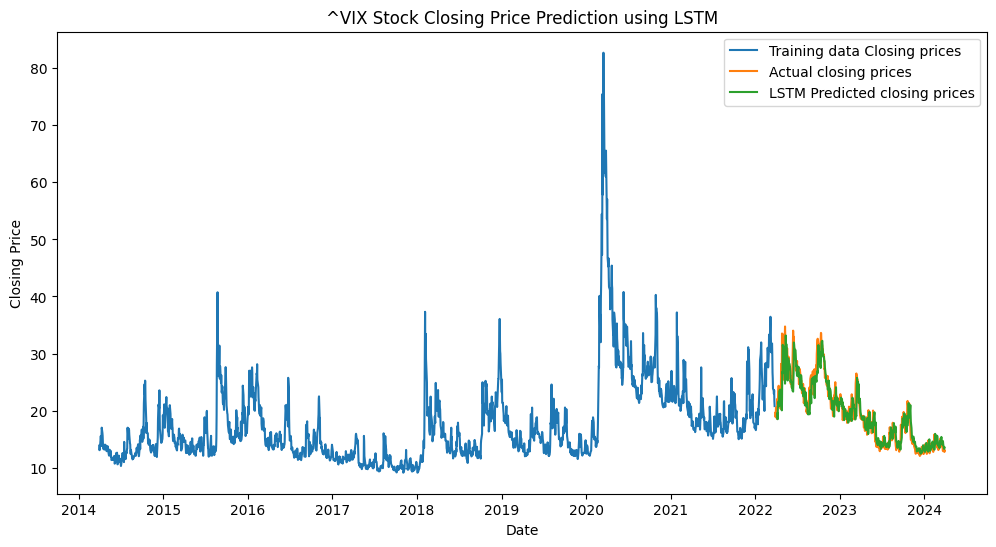

In [15]:
# Display actual vs. predicted closing prices
plt.figure(figsize=(12, 6))
plt.plot(closing_prices[:-len(test_data_index)], label="Training data Closing prices")
plt.plot(closing_prices[-len(test_data_index):], label="Actual closing prices")
plt.plot(test_data_index[7:], test_predict[:-1], label="LSTM Predicted closing prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title(f"{symbols} Stock Closing Price Prediction using LSTM")
plt.legend()
plt.show()

###Prophet Model

In [51]:
from prophet import Prophet
from functools import reduce

In [52]:
stock_price = data['close']
stock_price = stock_price.reset_index()
stock_price = stock_price.rename(columns={'date': 'ds', 'close': 'y'})
print(stock_price.head())

          ds      y
0 2014-03-31  13.88
1 2014-04-01  13.10
2 2014-04-02  13.09
3 2014-04-03  13.37
4 2014-04-04  13.96


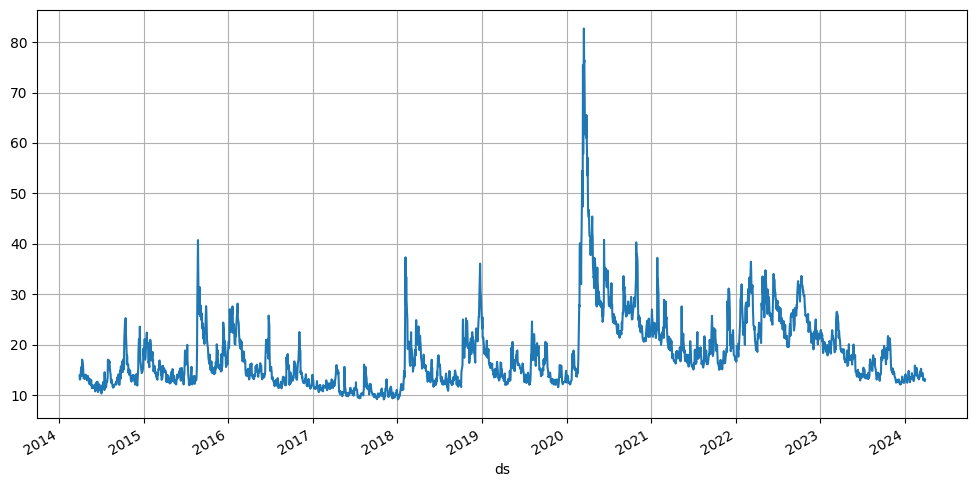

In [53]:
stock_price.set_index('ds').y.plot(figsize=(12,6), grid=True);

In [54]:
model = Prophet()
model.fit(stock_price)

16:43:37 - cmdstanpy - INFO - Chain [1] start processing
16:43:40 - cmdstanpy - INFO - Chain [1] done processing


In [55]:
#To create a forecast with our model we need to create some futue dates. 
# Prophet provides us with a helper function called make_future_dataframe. 
# We pass in the number of future periods and frequency. Above we created a forecast for the next 1095 days or 3 years.

#Since stocks can only be traded on weekdays we need to remove the weekends 
# from our forecast dataframe. To do so we create a boolean expression where 
# if a day does not equal 0 - 4 then return False. "0 = Monday, 6=Saturday, etc.."

#We then pass the boolean expression to our dataframe with returns only True values.
#  We now have a forecast dataframe comprised of the next 3 years of weekdays.

In [56]:
future = model.make_future_dataframe(1095, freq='d')

future_boolean = future['ds'].map(lambda x : True if x.weekday() in range(0, 5) else False)
future = future[future_boolean] 

future.tail()

,ds
3605,2027-03-22
3606,2027-03-23
3607,2027-03-24
3608,2027-03-25
3609,2027-03-26


In [57]:
#To create the forecast we call predict from our model and pass in the future dataframe we created earlier. 
# We return the results in a new dataframe called forecast.

#When we inspect the forecast dataframe we see a bunch of new terms. 
# The one we are most interested in is yhat which is our forecasted value.

In [58]:
forecast = model.predict(future)

In [59]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
3293,2027-03-22,-6.609364,-38.108161,34.789420,-41.896205,30.623005,4.187589,4.187589,4.187589,0.061684,0.061684,0.061684,4.125905,4.125905,4.125905,0.0,0.0,0.0,-2.421775
3294,2027-03-23,-6.627162,-37.809737,34.200605,-41.985906,30.722016,3.961997,3.961997,3.961997,-0.033614,-0.033614,-0.033614,3.995611,3.995611,3.995611,0.0,0.0,0.0,-2.665165
3295,2027-03-24,-6.644961,-38.761342,35.283320,-42.075606,30.759251,3.726840,3.726840,3.726840,-0.120138,-0.120138,-0.120138,3.846978,3.846978,3.846978,0.0,0.0,0.0,-2.918120
3296,2027-03-25,-6.662759,-38.705498,34.959255,-42.165307,30.748602,3.645310,3.645310,3.645310,-0.036443,-0.036443,-0.036443,3.681753,3.681753,3.681753,0.0,0.0,0.0,-3.017449
3297,2027-03-26,-6.680557,-39.320673,34.073645,-42.248763,30.786642,3.208492,3.208492,3.208492,-0.293338,-0.293338,-0.293338,3.501830,3.501830,3.501830,0.0,0.0,0.0,-3.472065


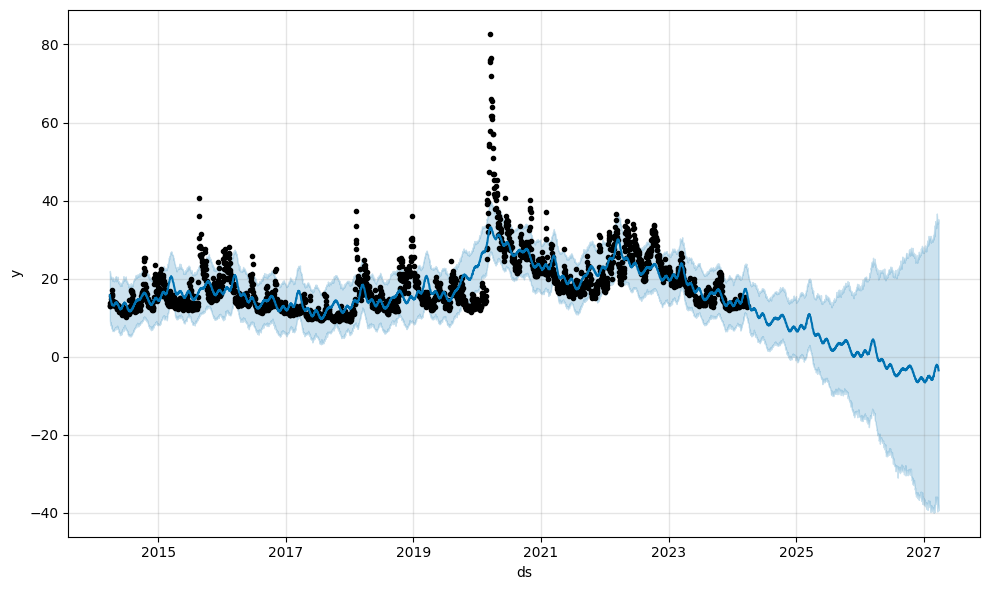

In [60]:
model.plot(forecast);

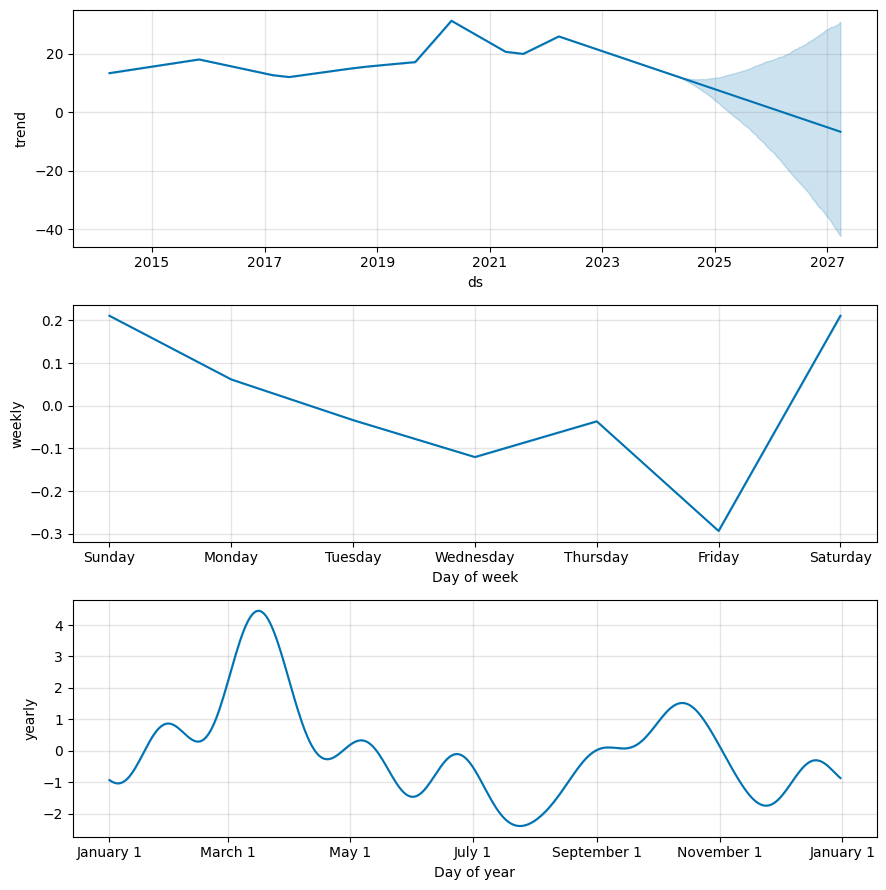

In [61]:
model.plot_components(forecast);

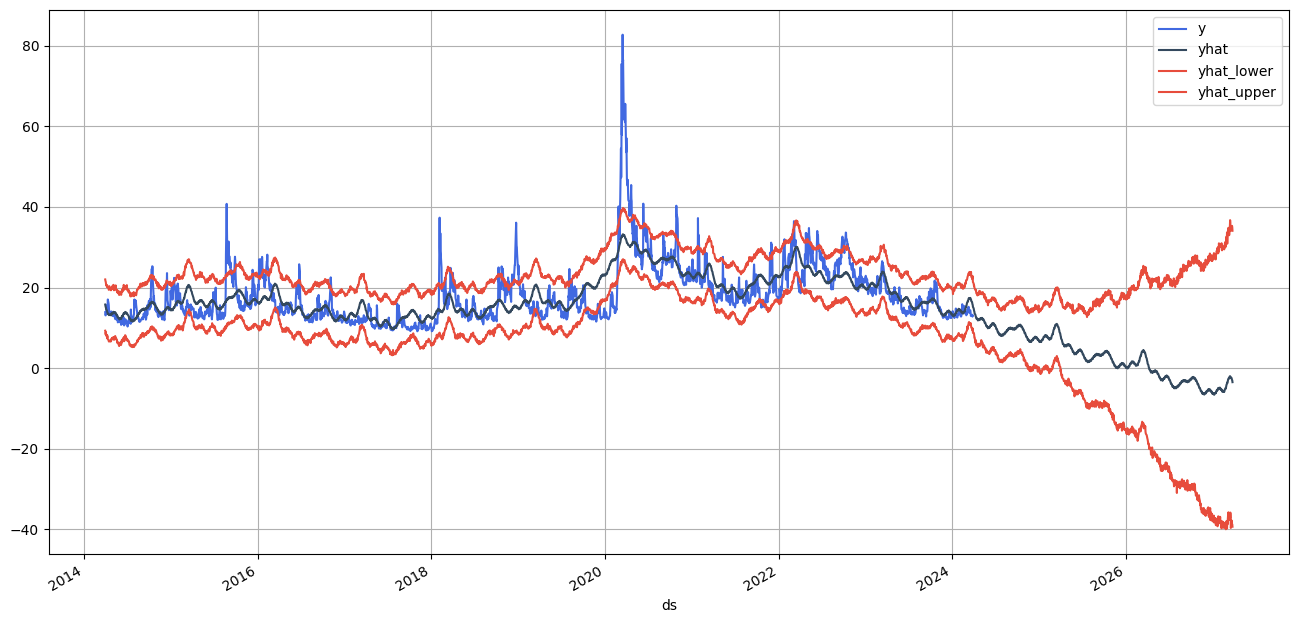

In [62]:
stock_price_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
df = pd.merge(stock_price, stock_price_forecast, on='ds', how='right')
df.set_index('ds').plot(figsize=(16,8), color=['royalblue', "#34495e", "#e74c3c", "#e74c3c"], grid=True);